# CS 615 Final Project: Recipe Quality Prediction and Semantic Clustering
**Author:** Ian Auger

## Introduction
Online recipe platforms exhibit a strong positivity skew, where many recipes receive highly favorable star ratings even when critical qualitative feedback is present in the accompanying review text. As a result, important signals such as flavor issues, preparation difficulty, or ingredient problems are often diluted within large volumes of uniformly positive reviews.

**Objective.** The goal of this project is to build a deep learning system that predicts a stabilized recipe-quality score by combining structured recipe metadata with semantic feedback signals extracted from user reviews.

### Phase 1 Retrospective: Data Engineering and Distributed NLP
This project builds directly on a prior phase completed in DSCI 632. In that earlier work, the focus was on transforming unstructured Food.com review text into structured multi-label semantic signals using a distributed PySpark pipeline.

Key components of Phase 1 included:
- **Qualitative Tagging via Distributed NLP:** A transformer-based zero-shot baseline was used to generate silver labels, which were then used to support a scalable Word2Vec-centroid tagging system in PySpark.
- **Culinary Semantic Representation:** Reviews were embedded in a custom 128-dimensional culinary vector space, enabling the extraction of both common praise signals and rarer critique-oriented signals such as difficulty, dryness, excessive sweetness, or ingredient issues.

A key challenge in this dataset is that user-provided ratings are heavily skewed toward positive values, limiting their ability to differentiate between bad, mediocre and truly exceptional recipes. This challenge was felt during the initial phase of the project, with negative tags exhibiting a difficulty to be precisely assigned due to the lack of supporting evidence within the full corpus of reviews. Future iterations of the tagging pipeline will work to add precision to the negative review tagging, but this deficiency is felt upstream during this phase of the project. 

The deep learning phase begins where that pipeline ends: with recipe-level aggregates of these semantic review features merged with structured recipe metadata. The remainder of this report evaluates several neural architectures designed to integrate these heterogeneous signals and examines how architectural design influences both predictive accuracy and representation structure.

In [1]:
# Core Libraries
import sys

# Dynamic Path Setup to Ensure src is Importable
from pathlib import Path
p = Path.cwd().resolve()
while p != p.parent and not (p / "src").exists():
    p = p.parent
if str(p) not in sys.path:
    sys.path.insert(0, str(p))

# Internal Pipeline Modules
from src.config import load_settings
from src.dataset import RecipeDataset
from src.preprocessing import preprocess_data
from src.visualizations import (
    rating_distribution_plots,
    generate_alltime_leaderboard,
    generate_hp_leaderboard,
    plot_recipe_manifold,
    summarize_inference_metrics,
    plot_regression_diagnostics,
    show_largest_prediction_errors,
    plot_umap_grid,
    calculate_spearmanr
)

# Setup Environment
s = load_settings()

## Preprocessing: Target Formulation and Feature Engineering
The deep learning stage begins with a recipe-level table formed by combining original Food.com recipe metadata with aggregated semantic review signals from Phase 1. Before modeling, these raw inputs required additional engineering to produce a numerically stable supervised learning dataset.

### Target Engineering: Bayesian Smoothing
Raw average ratings on recipe websites are highly sensitive to low-sample variance. For example, a recipe with a single 5-star review can outrank a recipe with dozens of consistently high ratings simply because its estimate is based on almost no evidence. To reduce this instability, the project uses a **Bayesian-smoothed rating** as the regression target.

This target combines:
- **A global prior ($C$):** the mean rating across the full recipe population
- **A confidence threshold ($m$):** based on the upper quantiles of review counts
- **A weighted adjustment:** recipes with few reviews are shrunk toward the global mean, while highly reviewed recipes remain closer to their observed average

This produces a more stable continuous target that is better suited for regression than the raw mean rating alone.

### Feature Engineering
To construct the final model inputs, the preprocessing pipeline performs several deterministic transformations:

- **Structured metadata extraction:** Recipe-level structural and nutritional attributes such as `minutes`, `n_steps`, `n_ingredients`, `calories`, `sodium`, and `protein` are retained as continuous features.
- **Semantic review aggregation:** Review-level NLP outputs from Phase 1 are grouped to the recipe level. Tag prevalence features (`pred_*`) summarize how frequently a semantic signal appears across reviews, while tag intensity features (`intensity_*`) summarize the average strength of that signal.
- **Categorical encoding:** Cleaned recipe tags and ingredients are converted into one-hot encoded indicators for the most common categories, reducing cardinality while preserving interpretable recipe context.
- **Min-max scaling:** Continuous numerical features are rescaled to the `[0, 1]` range so they can be optimized more consistently alongside sparse binary inputs such as category and ingredient indicators.

These features transform sparse, noisy review text and structured metadata into a dense representation suitable for neural modeling.

## Exploratory Data Analysis
Before comparing architectures, it is useful to inspect the dimensionality of the final dataset and evaluate how Bayesian smoothing changes the target distribution. This section summarizes the size of the modeling table and contrasts the raw mean rating distribution with the engineered Bayesian target.

In [2]:
# Load the preprocessed Phase 1 dataset
df = preprocess_data(s, overwrite_processed=False)
full_dataset = RecipeDataset(df)

# Data
print(f"Total Recipes: {len(full_dataset):,}")
print(f"Metadata Features: {full_dataset.meta_dim}")
print(f"Tag Features: {full_dataset.tag_dim}")
print(f"Continuous Metadata Features: {full_dataset.num_dim}")
print(f"Categorical Metadata Features: {full_dataset.cat_dim}")

df[['raw_mean_rating', 'review_count', 'bayesian_rating']].describe().T

File already exists: C:\Users\iauge\Documents\Drexel MSDS\CS 615\Project\data\processed\PROCESSED_recipes.parquet
Total Recipes: 173,550
Metadata Features: 210
Tag Features: 34
Continuous Metadata Features: 10
Categorical Metadata Features: 200


,count,mean,std,min,25%,50%,75%,max
raw_mean_rating,173550.0,4.577309,0.598100,1.00000,4.333333,4.800000,5.000000,5.000000
review_count,173550.0,5.743181,18.822915,1.00000,1.000000,2.000000,5.000000,1496.000000
bayesian_rating,173550.0,4.616015,0.366879,1.61025,4.415375,4.777707,4.887166,4.998246


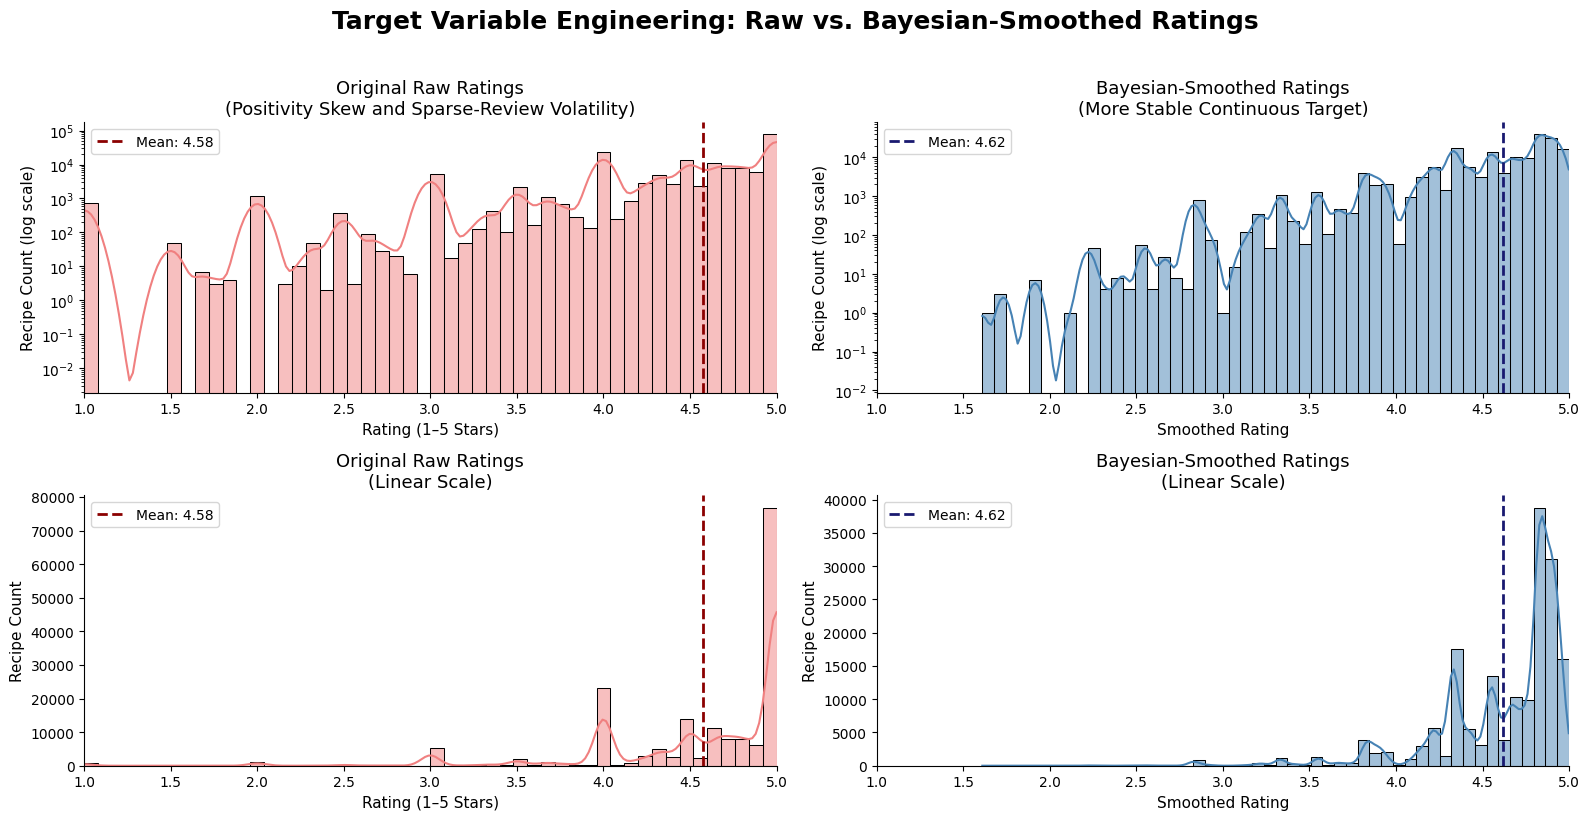

In [3]:
rating_distribution_plots(df, raw_col='raw_mean_rating', smooth_col='bayesian_rating')

### Rating Smoothing Analysis

The raw rating distribution shows a strong **positivity skew**, with most recipes concentrated between roughly 4 and 5 stars. The log-scaled view highlights another issue: recipes with very few reviews create scattered low-frequency bins across the rating range, reflecting **high variance from sparse feedback**.

To reduce this instability, the model predicts a **Bayesian-smoothed rating** rather than the raw mean rating. This approach shrinks recipes with few reviews toward the global average while allowing highly reviewed recipes to retain their observed scores.

The resulting target remains positively skewed but is **more stable and less dominated by small-sample noise**, making it a more reliable regression target for the neural network.

## Model Architecture

During the modeling phase I implemented a framework that allowed for testing multiple model variations. The goal of this comparison is to isolate how depth and residual connections affect both optimization stability and the structure of learned embeddings. 

To model recipe quality, I used a **dual-stream neural architecture** that processes two distinct feature groups:

1. **Recipe Metadata**
   - structural properties (minutes, steps, ingredients)
   - nutritional information (calories, fat, sodium, etc.)
   - categorical recipe tags
   - ingredient indicators

2. **Semantic Review Signals**
   - aggregated qualitative feedback derived from Phase 1 NLP tagging
   - tag prevalence features (`pred_*`)
   - tag intensity features (`intensity_*`)

These two feature families capture fundamentally different information. Metadata describes **what the recipe is**, while semantic review features describe **how users experienced it**.

### Dual-Encoder Design

To reflect this distinction, the model first encodes metadata and semantic review features **separately** using independent feature transformations. The resulting representations are then **fused into a shared latent representation** used to predict recipe quality.

### Architecture Variants

Several architectural heads were tested to examine how **network depth, residual structure, and feature fusion strategy** influence model performance.

- **Shallow MLP**  
  A simple feedforward baseline operating on the fused representation. This model provides a reference point for evaluating the benefits of deeper architectures.

- **Deep MLP**  
  A deeper fully connected network applied to the fused representation, allowing the model to capture more complex nonlinear interactions between metadata and review-derived features.

- **Residual Networks**  
  Skip-connected architectures designed to stabilize optimization in deeper networks and encourage feature reuse by allowing gradients to propagate through identity pathways.

  - **Residual**  
    A baseline residual architecture consisting of stacked fully connected layers connected through identity skip connections. These residual links allow the network to learn feature refinements relative to earlier representations, reducing vanishing-gradient issues and enabling deeper networks to train more reliably.

  - **Residual_V2**  
    An enhanced residual design that introduces **normalization layers within each residual block**. Normalization stabilizes activation distributions during training, improving optimization dynamics and helping the network converge more consistently. This architecture ultimately produced the most stable training behavior and smoother latent representations.

  - **Residual_V3**  
    An experimental variant incorporating **PLQP-style gated transformations** within residual blocks. Instead of simple additive residual updates, these blocks learn parameterized transformations that adaptively reshape intermediate representations. While this increases model expressiveness, it did not consistently improve performance in this study.

- **Two-Tower Architecture**  
  Separate deep encoders are used for metadata and semantic review features. The two representations are fused only at the final prediction stage, allowing each tower to learn specialized feature transformations before interaction.

All architectures share the same preprocessing pipeline and target variable, allowing a controlled comparison of how architectural design influences predictive performance and representation structure.

## Experimental Framework

To compare the candidate architectures under controlled conditions, each model was trained using the same preprocessing pipeline, target variable, and train/validation/test split. This ensures that differences in performance reflect architectural design rather than changes in data preparation or evaluation procedure. Early stopping based on validation loss was used to prevent overfitting and ensure stable convergence across architectures.

The experimental framework was implemented in `main.py`, which systematically iterates over combinations of:

- **Architecture head** (`shallow`, `deep`, `residual`, `residual_v2`, `residual_v3`, `two_tower`)
- **Feature ablation setting** (`all_features`, `meta_only`, `tag_only`)
- **Loss function** (`MSE`, `Huber`, `Log-Cash`)

For each run, the training loop recorded:
- training loss
- validation loss
- gradient norm statistics
- final test-set metrics (RMSE, MAE, MSE)

The resulting JSON logs were then aggregated into a leaderboard, allowing direct comparison of predictive performance across architectures and feature conditions. 

### Leaderboard Results

The leaderboard summarizes the results of the controlled architecture sweep described in the experimental framework. Each entry corresponds to a model trained using the same preprocessing pipeline, feature set, and data split, allowing architectural differences to be evaluated in isolation.

Models are ranked according to test-set RMSE, with additional metrics including MAE and MSE reported to provide complementary views of prediction error.

These results provide a quantitative comparison of the candidate architectures and help identify which designs merit deeper inspection through representation analysis and embedding visualization.

In [4]:
generate_alltime_leaderboard(s.results_dir, mode="best_per_model_ablation", sort_by="test_rmse")


=== Best Run per Model × Ablation ===
| Run Date      | Architecture   | Ablation     | Loss     |   RMSE |    MAE |    MSE |   Best Val Loss |   Epochs |
|:--------------|:---------------|:-------------|:---------|-------:|-------:|-------:|----------------:|---------:|
| Mar 13, 17:03 | deep           | all_features | mse      | 0.2964 | 0.2189 | 0.0878 |          0.0842 |       87 |
| Mar 13, 16:09 | shallow        | all_features | huber    | 0.2964 | 0.2164 | 0.0878 |          0.0412 |       68 |
| Mar 13, 18:44 | residual_v2    | all_features | mse      | 0.2973 | 0.2196 | 0.0884 |          0.0843 |       50 |
| Mar 13, 17:41 | residual       | all_features | huber    | 0.2975 | 0.2162 | 0.0885 |          0.0417 |       54 |
| Mar 13, 20:06 | two_tower      | all_features | huber    | 0.298  | 0.2154 | 0.0888 |          0.0419 |       80 |
| Mar 13, 19:17 | residual_v3    | all_features | huber    | 0.2997 | 0.2183 | 0.0898 |          0.0419 |       51 |
| Mar 12, 18:06 | residua

### Leaderboard Analysis

Models trained with all features consistently achieve the best performance, with RMSE values around 0.296–0.301, indicating that combining recipe metadata and review-derived tags provides the strongest predictive signal. When using tag-only features, performance declines moderately but remains competitive, suggesting that review tags capture meaningful information about recipe quality. In contrast, metadata-only models perform substantially worse (RMSE ≈ 0.373), highlighting the importance of semantic signals derived from reviews. Differences between architectures are relatively small, indicating that feature representation has a larger impact on performance than network design in this task. Loss function optimization appear to be more model specific than generalizable across the full set of models. 

## Hyperparameter Grid Search

After identifying the strongest architectural configurations from the initial leaderboard, a targeted **hyperparameter grid search** was performed to refine training dynamics and improve convergence behavior. Rather than repeating the full architecture sweep, this search focused on the most competitive configuration identified during the initial experiments: a **deep architecture trained with all features using Huber loss**.

The grid search evaluated combinations of three key optimization parameters:

- **Learning Rate:** `[1e-3, 5e-4, 1e-4]`
- **Weight Decay:** `[1e-4, 1e-5, 0.0]`
- **Batch Size:** `[128, 256, 512]`

For each parameter combination, the training pipeline was executed using the same preprocessing pipeline and train/validation/test split to ensure consistent evaluation across runs.

Each experiment was automatically logged with a unique identifier encoding the hyperparameter values, allowing results to be tracked and incorporated into the experiment leaderboard for comparison. The resulting experiments provided additional insight into training stability and informed the final architecture comparisons discussed in the following sections.

In [5]:
hp_leaderboard = generate_hp_leaderboard(s.results_dir)


=== Hyperparameter Grid Search Leaderboard ===
| Run Date      | Architecture   |     LR |   Batch |   Decay | Ablation     | Loss   |   RMSE |    MSE |    MAE |   Epochs |
|:--------------|:---------------|-------:|--------:|--------:|:-------------|:-------|-------:|-------:|-------:|---------:|
| Mar 12, 23:13 | deep           | 0.0001 |     256 |  0      | all_features | huber  | 0.2967 | 0.088  | 0.2208 |      105 |
| Mar 13, 00:45 | deep           | 0.0005 |     512 |  0      | all_features | huber  | 0.2969 | 0.0881 | 0.2195 |       77 |
| Mar 13, 00:13 | deep           | 0.0005 |     512 |  0.0001 | all_features | huber  | 0.297  | 0.0882 | 0.2192 |       66 |
| Mar 12, 20:10 | deep           | 0.0001 |     128 |  1e-05  | all_features | huber  | 0.2973 | 0.0884 | 0.2202 |       80 |
| Mar 13, 00:01 | deep           | 0.001  |     512 |  0      | all_features | huber  | 0.2979 | 0.0887 | 0.2206 |       52 |
| Mar 12, 23:40 | deep           | 0.001  |     512 |  0.0001 | all_fe

### Hyperparameter Grid Search Analysis

The hyperparameter grid search refined the best-performing architecture by evaluating combinations of **learning rate, batch size, and weight decay** for the deep model trained on the full feature set with Huber loss.

The best configuration achieved an **RMSE of 0.2967** using:

- **Learning Rate:** 1e-4  
- **Batch Size:** 256  
- **Weight Decay:** 0.0  

Overall performance across the grid was relatively stable, with most configurations falling within **0.296–0.301 RMSE**, indicating that the model is fairly robust to moderate changes in optimization parameters.

Several patterns emerge from the results. Lower learning rates generally produced more stable outcomes, while very large batch sizes (512) occasionally introduced instability, including a few clear outliers with significantly worse performance. Weight decay had minimal impact on accuracy in this task, suggesting that the model does not suffer heavily from overfitting under the current architecture and dataset size.

Based on these results, the configuration **LR = 1e-4, batch size = 256, weight decay = 0** was selected as the final training setup for the optimized model variants.

### Embedding Manifold Comparison Across Architectures

While predictive performance across the full-feature models was very similar (all within ~0.003 RMSE), the learned **latent embedding spaces** differ substantially across architectures. Because the downstream system uses these embeddings for **semantic reranking and similarity search**, the geometric structure of the embedding space is an important model selection criterion alongside predictive accuracy.

To evaluate the quality of the learned representations, the final embedding layer from each top model variant was extracted and projected into two dimensions using **UMAP**. Each point in the figure represents a recipe from the held-out test set, colored by its Bayesian-smoothed rating. Models that produce smoother manifolds, clearer neighborhood structure, and consistent rating gradients are more suitable for semantic retrieval tasks.

The grid below compares the embedding manifolds produced by six architectures: **Shallow, Deep, Residual, Residual V2, Residual V3, and Two-Tower**. This visualization allows us to assess how different model designs influence the organization of recipe representations in latent space, independent of small differences in predictive error.

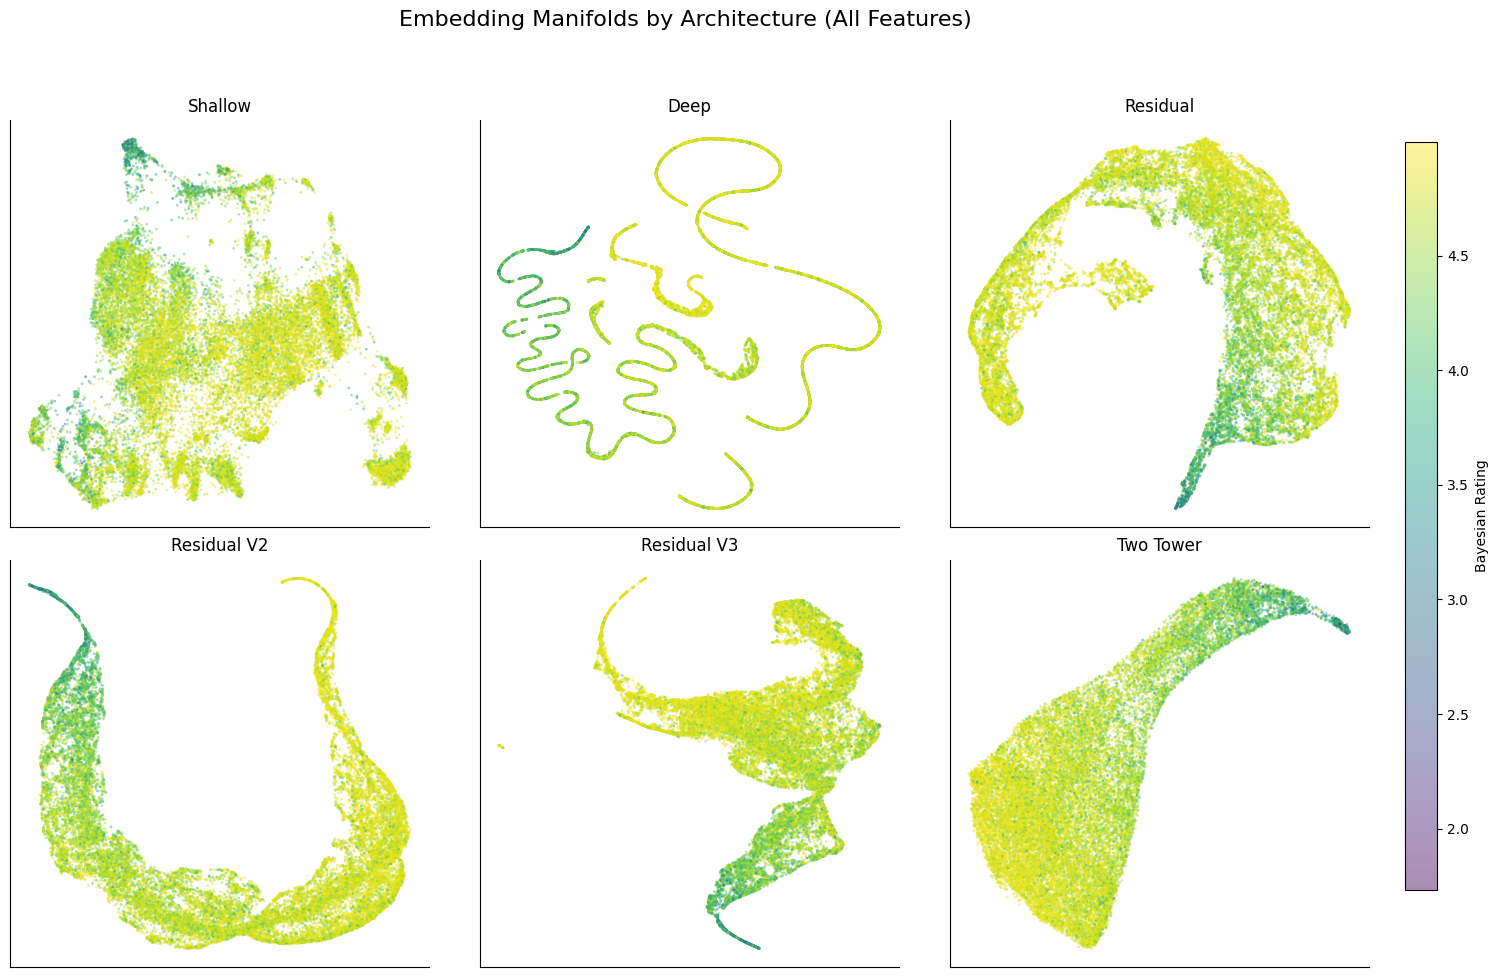

In [6]:
plot_umap_grid()

### Manifold Analysis

Although predictive performance across architectures differed only marginally, the resulting embedding geometries varied substantially. The **Deep** architecture collapses the representation into narrow trajectories, suggesting the model primarily learned a near one-dimensional rating axis rather than a richer semantic representation. In contrast, the **Residual** and **Two-Tower** architectures produce smoother, more continuous manifolds that better preserve local neighborhood structure and allow recipes with similar qualitative characteristics to cluster together.

Because these embeddings will be reused for **semantic retrieval and reranking**, architectures that produce more structured latent spaces are preferred over those optimized solely for predictive accuracy. For this reason, only the **`residual_v2`** and **`two_tower`** models were carried forward into the full inference stage for final comparison.

## Inference Evaluation

The manifold analysis in the previous section narrowed the candidate architectures to **Residual V2** and **Two-Tower**, both of which produced structured embedding spaces suitable for downstream retrieval tasks. The final step is therefore to compare these two models directly on the inference datasets and determine which architecture should serve as the final scoring model.

The model predicts a **Bayesian-smoothed recipe rating**, bounded approximately between **1 and 5 stars**. Because this score will ultimately be used as a **semantic re-ranking signal within the information retrieval pipeline**, it is important to verify that predictions remain stable, unbiased, and well-calibrated across the rating spectrum.

To make the final decision, we examine several complementary diagnostics:

- **Predicted vs. Actual Ratings**  
  This plot compares predicted scores with the true ratings. A well-calibrated model should place points close to the **45° diagonal**, indicating strong agreement between predicted and observed values.

- **Residual Distribution**  
  Examining the distribution of residuals helps determine whether prediction errors are **centered around zero** and whether large deviations occur systematically or only in isolated cases.

- **Residuals vs. Actual Ratings**  
  Plotting residuals against the true rating helps detect **systematic error patterns** across the rating range. Ideally, residuals should appear randomly distributed around zero with no clear trend.

- **Largest Error Inspection**  
  Reviewing recipes with the largest absolute prediction errors provides a qualitative check for **outliers or unusual cases**, helping confirm that large deviations reflect genuinely difficult predictions rather than structural model issues.

- **Spearman Correlation**  
  Spearman correlation measures the **monotonic relationship** between predicted and actual ratings. Because the predicted score will be used for **ranking**, a strong Spearman correlation indicates that the model preserves the correct ordering of recipes even when absolute errors occur.

Together, these diagnostics provide a comprehensive view of model behavior and support the final architecture selection.

== Residual Error Summary ==
Residual V2:
|   RMSE |    MAE |    MSE |   Mean Actual |   Mean Predicted |   Mean Residual |
|-------:|-------:|-------:|--------------:|-----------------:|----------------:|
|  0.289 | 0.2145 | 0.0835 |         4.616 |           4.6236 |         -0.0076 |

Two Tower:
|   RMSE |    MAE |    MSE |   Mean Actual |   Mean Predicted |   Mean Residual |
|-------:|-------:|-------:|--------------:|-----------------:|----------------:|
| 0.2896 | 0.2099 | 0.0838 |         4.616 |           4.6397 |         -0.0236 |

== Regression Diagnostics ==
Residual V2:


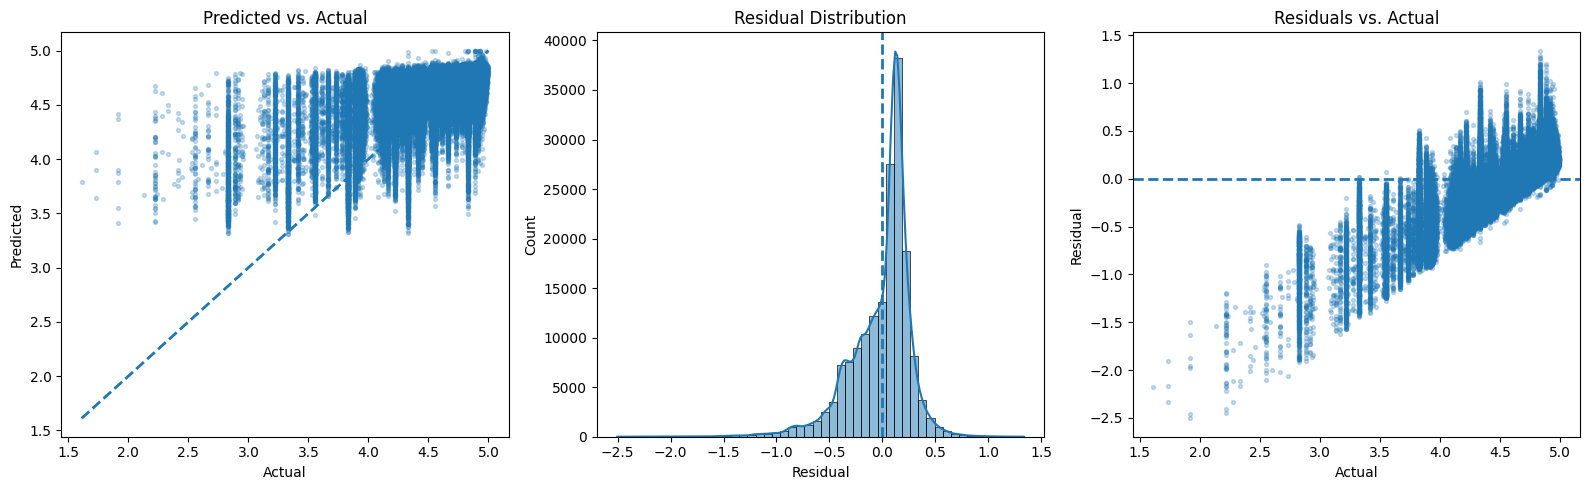

Two Tower:


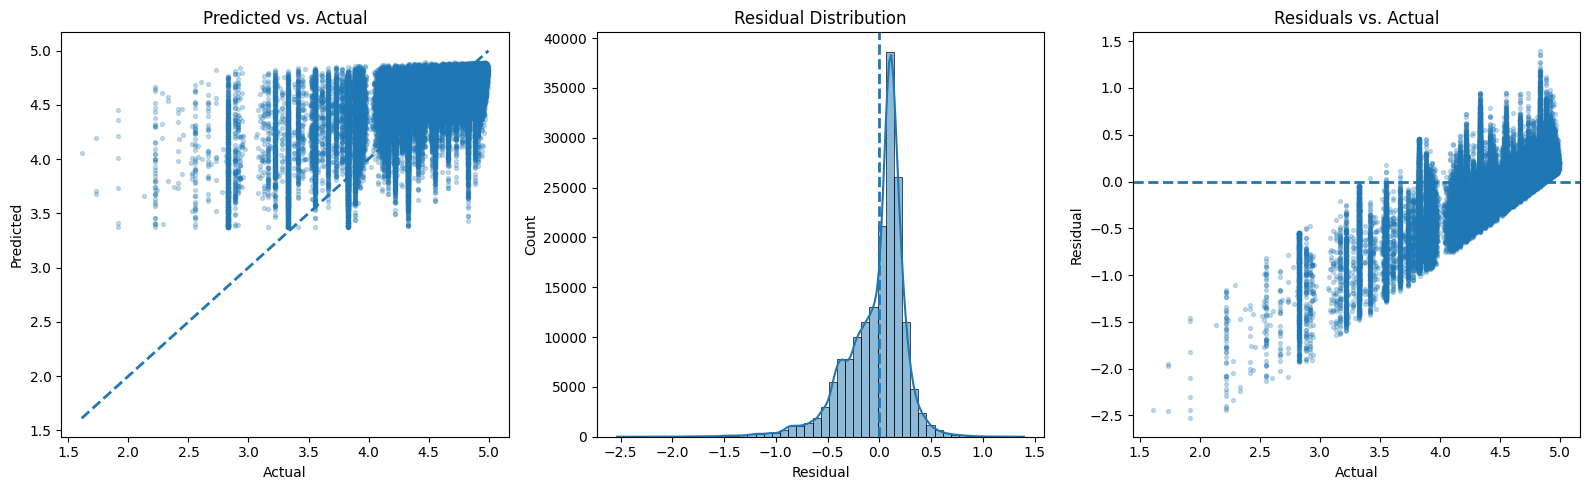


== Largest Prediction Errors ==
Residual V2:


,recipe_name,recipe_id,actual,predicted,residual,abs_error
0,basic brown rice,407040,1.915375,4.419396,-2.504022,2.504022
1,sushi now sushi rice,261311,1.915375,4.372796,-2.457421,2.457421
2,filipino lumpia,344469,2.220500,4.672064,-2.451565,2.451565
3,your favorite meatloaf with a twist,17571,2.220500,4.624188,-2.403688,2.403688
4,iranian barbari bread,211029,1.732300,4.066808,-2.334508,2.334508
5,the worst english muffin pizza the saddest ...,404178,2.276917,4.605496,-2.328579,2.328579
6,texas best chili adopted not tried yet,45708,2.220500,4.435646,-2.215147,2.215147
7,ruby tuesday s buffalo chicken wontons,146404,2.220500,4.399643,-2.179144,2.179144
8,pecan pie jam,28221,1.610250,3.786593,-2.176343,2.176343
9,stove top brownies,355387,2.332300,4.502748,-2.170448,2.170448


Two Tower:


,recipe_name,recipe_id,actual,predicted,residual,abs_error
0,basic brown rice,407040,1.915375,4.447463,-2.532088,2.532088
1,iranian barbari bread,211029,1.732300,4.190826,-2.458527,2.458527
2,sushi now sushi rice,261311,1.915375,4.361280,-2.445906,2.445906
3,pecan pie jam,28221,1.610250,4.052187,-2.441937,2.441937
4,texas best chili adopted not tried yet,45708,2.220500,4.662365,-2.441865,2.441865
5,filipino lumpia,344469,2.220500,4.641028,-2.420529,2.420529
6,your favorite meatloaf with a twist,17571,2.220500,4.625854,-2.405354,2.405354
7,the worst english muffin pizza the saddest ...,404178,2.276917,4.610741,-2.333824,2.333824
8,copycat of zaxby s chicken fingers,488933,1.915375,4.216752,-2.301377,2.301377
9,ruby tuesday s buffalo chicken wontons,146404,2.220500,4.517579,-2.297080,2.297080



== Spearman Correlation ==
Residual V2:
Spearman's Rank Correlation: 0.5080 (p-value: 0.0000e+00)
Two Tower:
Spearman's Rank Correlation: 0.5054 (p-value: 0.0000e+00)


In [7]:
# Inference Analysis for Two Tower
two_tower_bundle_path = str(Path(s.best_model_dir) / "final_two_tower_embeddings.pt")
residual_v2_bundle_path = str(Path(s.best_model_dir) / "final_residual_v2_embeddings.pt")


print("== Residual Error Summary ==")
print("Residual V2:")
summarize_inference_metrics(residual_v2_bundle_path)
print("\nTwo Tower:")
summarize_inference_metrics(two_tower_bundle_path)
print("\n== Regression Diagnostics ==")
print("Residual V2:")
plot_regression_diagnostics(residual_v2_bundle_path)
print("Two Tower:")
plot_regression_diagnostics(two_tower_bundle_path)
print("\n== Largest Prediction Errors ==")
print("Residual V2:")
res_recipes = show_largest_prediction_errors(residual_v2_bundle_path, top_n=10)
display(res_recipes)
print("Two Tower:")
two_tower_recipes = show_largest_prediction_errors(two_tower_bundle_path, top_n=10)
display(two_tower_recipes)
print("\n== Spearman Correlation ==")
print("Residual V2:")
calculate_spearmanr(residual_v2_bundle_path)
print("Two Tower:")
calculate_spearmanr(two_tower_bundle_path)

### Final Model Selection

Both candidate architectures produce nearly identical predictive performance.  
Spearman correlation on the inference dataset is **0.508 for Residual V2** and **0.505 for the Two-Tower model**, indicating that both models capture a comparable monotonic relationship between predicted and observed ratings. In practical terms, either architecture can provide a usable ranking signal.

However, this similarity in performance is partially driven by a shared limitation. The underlying rating distribution is heavily skewed toward positive values, and both models struggle to accurately differentiate among lower-rated recipes. This results in a compressed prediction range at the lower end of the scale, limiting the ability of either architecture to fully capture negative or mid-tier variation. As a result, overall ranking performance is dominated by distinguishing among moderately to highly rated recipes, where both models perform similarly well.

Predictive correlation is not the only objective of this system. The learned embeddings are intended to serve as semantic representations for retrieval and re-ranking, making the geometry of the embedding space an important design consideration. The earlier manifold analysis showed that the **Residual V2 architecture produces smoother and more coherent embedding structure**, preserving local neighborhood relationships more effectively than the Two-Tower representation.

Because predictive performance is effectively tied and both models struggle in similar patterns, the final decision can reasonably be guided by representation quality. The **Residual V2 model provides slightly stronger correlation while also producing richer embedding geometry**, making it the more suitable architecture for downstream retrieval tasks.

For these reasons, Residual V2 is selected as the final model used for full inference and embedding generation.

## Final Embedding Space for Residual_V2

To visualize the representation learned by the final model, the penultimate-layer recipe embeddings were projected into two dimensions using UMAP. Each point represents a recipe and is colored by its Bayesian-smoothed rating.

The projection reveals a large, continuous manifold that organizes recipes according to learned latent structure. Highly rated recipes (dark red) cluster along the outer arc of the manifold, while lower-rated recipes appear more frequently along the elongated lower branch. The smooth color gradient across the structure suggests that the model has learned a continuous representation of recipe quality rather than separating recipes into rigid clusters.

Because these embeddings will be reused for **semantic re-ranking within the information retrieval system**, this geometry is important: recipes that appear near one another in the embedding space are likely to share meaningful semantic characteristics, making the representation suitable for downstream retrieval and similarity tasks.

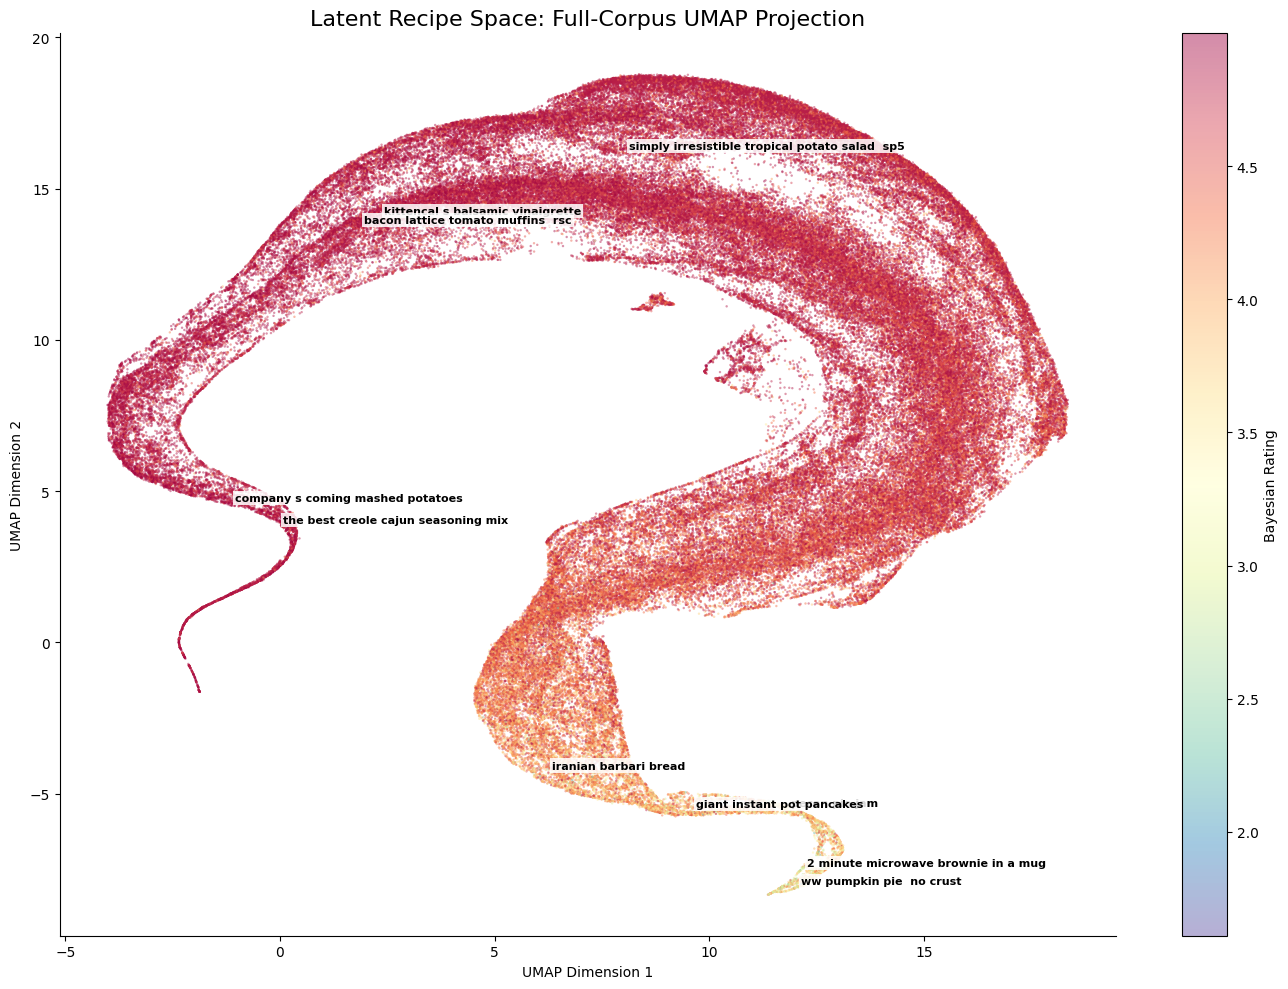

array([[14.271424  , 14.931443  ],
       [15.165576  ,  9.121739  ],
       [10.627417  , 12.977495  ],
       ...,
       [11.426687  , 13.481635  ],
       [-0.02358997,  2.5139222 ],
       [ 7.1240563 , -5.0676045 ]], dtype=float32)

In [8]:
projection_path = str(Path(s.best_model_dir) / "final_residual_v2_umap_projection.npy")

plot_recipe_manifold(
    bundle_path=residual_v2_bundle_path,
    projection_path=projection_path,
    save_projection=True
)

## Conclusion

This project examined how neural network architecture influences both predictive performance and representation quality when modeling recipe ratings from structured metadata and review-derived semantic signals. While shallow, deep, residual, and two-tower architectures produced broadly similar regression performance, their learned embedding structures differed substantially. Residual architectures, in particular, produced smoother and more coherent latent manifolds, preserving local neighborhood relationships that are valuable for downstream retrieval tasks.

The similarity in predictive performance is partially driven by the underlying rating distribution, which is heavily skewed toward positive values. As a result, all models exhibit limited sensitivity in distinguishing lower-rated recipes, with performance largely determined by their ability to rank moderately to highly rated items.

Based on inference diagnostics and full-corpus analysis, the Residual V2 architecture was selected as the final model. It achieved consistently stronger monotonic alignment with true ratings while producing a well-structured embedding space across the recipe corpus. These embeddings capture meaningful variation in recipe quality and similarity, forming a continuous latent representation suitable for semantic operations.

This representation can be directly integrated as a semantic re-ranking signal within an information retrieval pipeline, enabling search results to prioritize recipes that are not only textually relevant but also structurally aligned with high-quality examples. My goal in the next phase of this project will be to demonstrate how neural architectures can extend beyond prediction tasks to support more effective ranking and retrieval systems.